# Air quality

Annual mean PM2.5 (µg/m³) from Van Donkelaar V5.GL.04 (WashU ACAG), coarsened from 0.01° native to the 0.5° atlas grid via in-window mean, then sign-inverted so higher = cleaner air = better. Ocean cells are masked to `NaN` using `is_land` from `grid.nc`.

In [1]:
import xarray as xr

from common import RAW_DIR, load_grid, save_variable

VARIABLE = 'air_quality'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

## 1. Fetch raw data

Van Donkelaar V5.GL.04 annual PM2.5 (µg/m³), ~200 MB single NetCDF at 0.01° (~1 km) global coverage. At 0.5° target resolution that's ~50×50 native samples per cell, plenty to average. Downloaded once and cached under `variable_raw`.

Data is available from [https://wustl.box.com/v/ACAG-V5GL04-GWRPM25c0p10] download the most recent annual data for the global dataset and place it within the fiolder `data/raw/air_quality/V5GL04.HybridPM25.Global.nc`

In [2]:
nc_path = variable_raw / f'V5GL04.HybridPM25.Global.nc'

if nc_path.exists():
    import warnings
    warnings.warn(f"Please download {nc_path} as specified")

print(f'{nc_path.name}: {nc_path.stat().st_size / 1024**2:.0f} MB')

V5GL04.HybridPM25.Global.nc: 2 MB


/var/folders/hq/d3n2t3r135gfw07crm1cqnrh0000gn/T/ipykernel_1832/2657926480.py:5: UserWarning: Please download /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/raw/air_quality/V5GL04.HybridPM25.Global.nc as specified
  warnings.warn(f"Please download {nc_path} as specified")


## 2. Clean & transform

Open the file and pick out the PM2.5 field. V5.GL.04 stores it as `GWRPM25` (µg/m³) on `(lat, lon)`; older or sibling ACAG products sometimes use `PM25` / `latitude` / `longitude`, so we normalise the names before proceeding. Latitude is flipped to ascending order if needed so `coarsen` and `interp` behave predictably.

In [3]:
pm_ds = xr.open_dataset(nc_path)

rename = {}
if 'latitude' in pm_ds.dims:
    rename['latitude'] = 'lat'
if 'longitude' in pm_ds.dims:
    rename['longitude'] = 'lon'
if rename:
    pm_ds = pm_ds.rename(rename)

pm_name = 'GWRPM25' if 'GWRPM25' in pm_ds.data_vars else 'PM25'
pm25 = pm_ds[pm_name].astype('float32')

if pm25.lat.values[0] > pm25.lat.values[-1]:
    pm25 = pm25.reindex(lat=pm25.lat[::-1])

print(pm25)

<xarray.DataArray 'GWRPM25' (lat: 1230, lon: 3600)> Size: 18MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [2.2, 2.1, 2. , ..., 2.1, 2.1, 2.1],
       [2.1, 2.1, 2. , ..., 1.9, 2. , 2. ],
       [1.9, 1.9, 2. , ..., 2. , 2. , 2. ]],
      shape=(1230, 3600), dtype=float32)
Coordinates:
  * lat      (lat) float64 10kB -54.95 -54.85 -54.75 ... 67.75 67.85 67.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 179.9
Attributes:
    long_name:  Hybrid PM_2_._5 [\mug/m^3], at 0.10 x 0.10 degrees
    units:      [\mug/m^3]


## 3. Interpolate onto the grid

For each ~0.5° window in the PM2.5 raster, take the mean (concentration averages linearly, unlike ruggedness which uses std). `coarsen` with `boundary='trim'` drops the fractional row/column at the edge, `interp(method='nearest')` snaps to the atlas `grid.lat` / `grid.lon`. Sign is inverted (`-pm25`) so higher = cleaner air = better, matching the atlas convention. Ocean cells are masked out.

In [4]:
grid = load_grid()

target_lat_step = float(abs(grid.lat[1] - grid.lat[0]))
target_lon_step = float(abs(grid.lon[1] - grid.lon[0]))

lat_factor = max(1, round(target_lat_step / float(abs(pm25.lat[1] - pm25.lat[0]))))
lon_factor = max(1, round(target_lon_step / float(abs(pm25.lon[1] - pm25.lon[0]))))

pm25_coarse = pm25.coarsen(lat=lat_factor, lon=lon_factor, boundary='trim').mean()

values = (
    (-pm25_coarse)
    .interp(lat=grid.lat, lon=grid.lon, method='nearest')
    .astype('float32')
    .rename(VARIABLE)
    .where(grid.is_land == 1)
)

## 4. Plot

<Axes: title={'center': 'air_quality'}, xlabel='longitude', ylabel='latitude'>

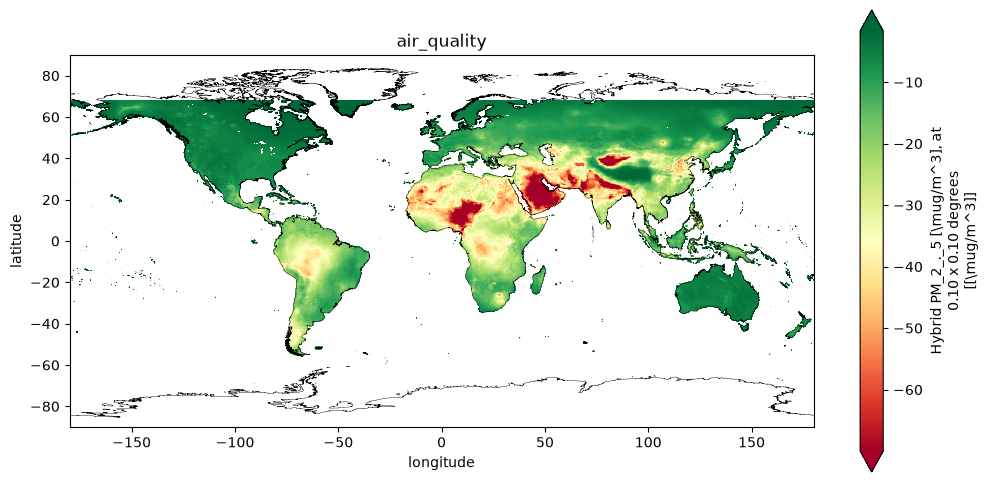

In [5]:
from common import plot_map

plot_map(values, cmap='RdYlGn', robust=True)

## 5. Save

In [6]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/air_quality.nc
